# Mechanistic Interpretability — Understanding What Models Learn

**Mechanistic interpretability** asks: *what algorithms do neural networks implement?* Not just *what does it predict* (post-hoc), but *how* — what circuits, features, and computations are embedded in the weights.

## Why It Matters
- Post-hoc methods (SHAP, LIME) approximate a black box from outside. Mechanistic interpretability opens the box.
- Critical for AI safety: if we understand exactly what a model has learned, we can verify alignment.
- Enables **circuit-level editing**: fix a bug in a model by modifying specific weights.

## Key Ideas
| Concept | Description |
|---------|-------------|
| **Features** | Directions in activation space that correspond to human-interpretable concepts |
| **Circuits** | Subgraphs of weights that implement specific algorithms |
| **Superposition** | Models store more features than dimensions by using interference |
| **Polysemanticity** | Single neurons respond to multiple unrelated concepts |
| **Induction Heads** | Attention heads that implement in-context learning |

## Post-hoc vs Mechanistic
```
Post-hoc (SHAP/LIME): input → [black box] → output, explain output
Mechanistic:         input → [W1 → a1 → W2 → a2] → output, understand EACH step
```

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

torch.manual_seed(42)
np.random.seed(42)

print('PyTorch version:', torch.__version__)
print('All imports successful')

PyTorch version: 2.12.1+cpu
All imports successful


## 1. Toy MLP: Visualising What Neurons Learn

We train a tiny 2-layer MLP on a synthetic binary classification task, then directly inspect the weight matrices to see what each neuron has learned.

$$h = \text{ReLU}(W_1 x + b_1), \quad \hat{y} = \sigma(W_2 h + b_2)$$

With only 2 input features and 5 hidden neurons, we can visualise each neuron's feature detector as a 2D vector.

Accuracy: 0.998


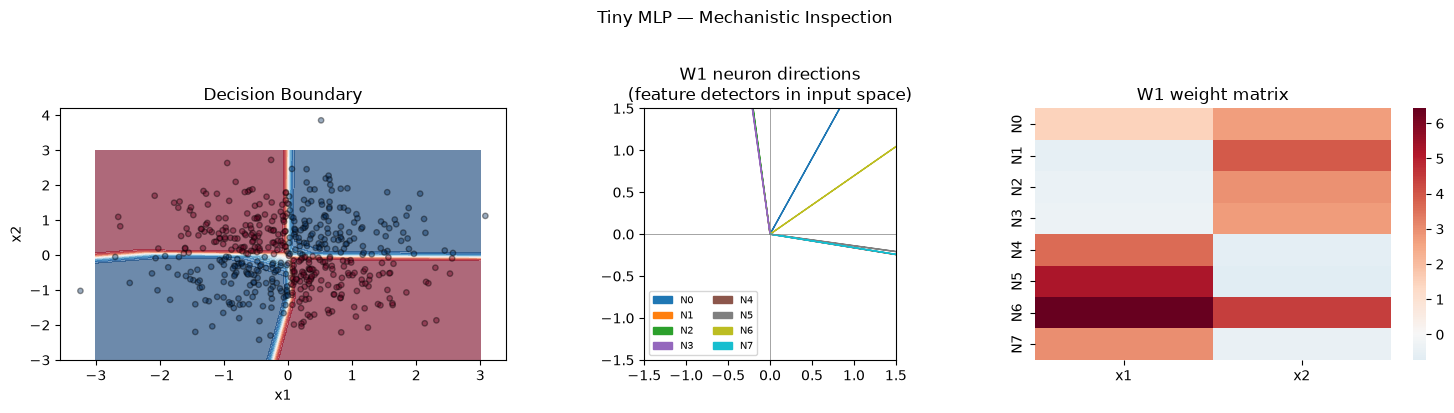

In [2]:
# ── Toy dataset: XOR-style problem in 2D ──
n = 500
X = np.random.randn(n, 2).astype(np.float32)
y = ((X[:, 0] * X[:, 1]) > 0).astype(np.float32)  # XOR quadrants

X_t = torch.tensor(X)
y_t = torch.tensor(y).unsqueeze(1)

# ── Tiny MLP ──
class TinyMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.W1 = nn.Linear(2, 8)
        self.W2 = nn.Linear(8, 1)
    def forward(self, x):
        return torch.sigmoid(self.W2(torch.relu(self.W1(x))))

model_mlp = TinyMLP()
opt = optim.Adam(model_mlp.parameters(), lr=0.01)
for _ in range(1000):
    loss = nn.BCELoss()(model_mlp(X_t), y_t)
    opt.zero_grad(); loss.backward(); opt.step()

with torch.no_grad():
    preds = (model_mlp(X_t) > 0.5).float().numpy().flatten()
print(f'Accuracy: {accuracy_score(y, preds):.3f}')

# ── Visualise W1 weights: each column is one neuron's feature detector ──
W1 = model_mlp.W1.weight.detach().numpy()  # (8, 2)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Decision boundary
xx, yy = np.meshgrid(np.linspace(-3, 3, 200), np.linspace(-3, 3, 200))
Zt = torch.tensor(np.c_[xx.ravel(), yy.ravel()].astype(np.float32))
with torch.no_grad(): Z = model_mlp(Zt).numpy().reshape(xx.shape)
axes[0].contourf(xx, yy, Z, levels=20, cmap='RdBu', alpha=0.6)
axes[0].scatter(X[:, 0], X[:, 1], c=y, cmap='RdBu', edgecolors='k', alpha=0.4, s=15)
axes[0].set_title('Decision Boundary')
axes[0].set_xlabel('x1'); axes[0].set_ylabel('x2')

# Each neuron as a vector from origin
axes[1].axhline(0, color='gray', lw=0.5); axes[1].axvline(0, color='gray', lw=0.5)
colors = plt.cm.tab10(np.linspace(0, 1, 8))
for i, (w, c) in enumerate(zip(W1, colors)):
    axes[1].arrow(0, 0, w[0], w[1], head_width=0.05, color=c, label=f'N{i}')
axes[1].set_xlim(-1.5, 1.5); axes[1].set_ylim(-1.5, 1.5)
axes[1].legend(fontsize=7, ncol=2)
axes[1].set_title('W1 neuron directions\n(feature detectors in input space)')
axes[1].set_aspect('equal')

# W1 heatmap
sns.heatmap(W1, ax=axes[2], cmap='RdBu_r', center=0,
            xticklabels=['x1', 'x2'], yticklabels=[f'N{i}' for i in range(8)])
axes[2].set_title('W1 weight matrix')

plt.suptitle('Tiny MLP — Mechanistic Inspection', y=1.02)
plt.tight_layout()
plt.show()

## 2. Superposition — Storing More Features Than Dimensions

The **Superposition Hypothesis** (Elhage et al., 2022) states:

> Neural networks *want* to represent more features than they have dimensions. They do this by **superimposing** feature vectors, tolerating interference.

**Why?** When features are *sparse* (rarely active), the expected interference is low. The model trades off:
- Interference penalty (features activate each other unintentionally)
- Benefit of representing more features

For $N$ features in $D$ dimensions with sparsity $1-p$:

$$\text{Expected interference loss} \approx p^2 \cdot \|W^\top W - I\|_F^2$$

When $p$ is small (sparse), interference is cheap → superposition wins.

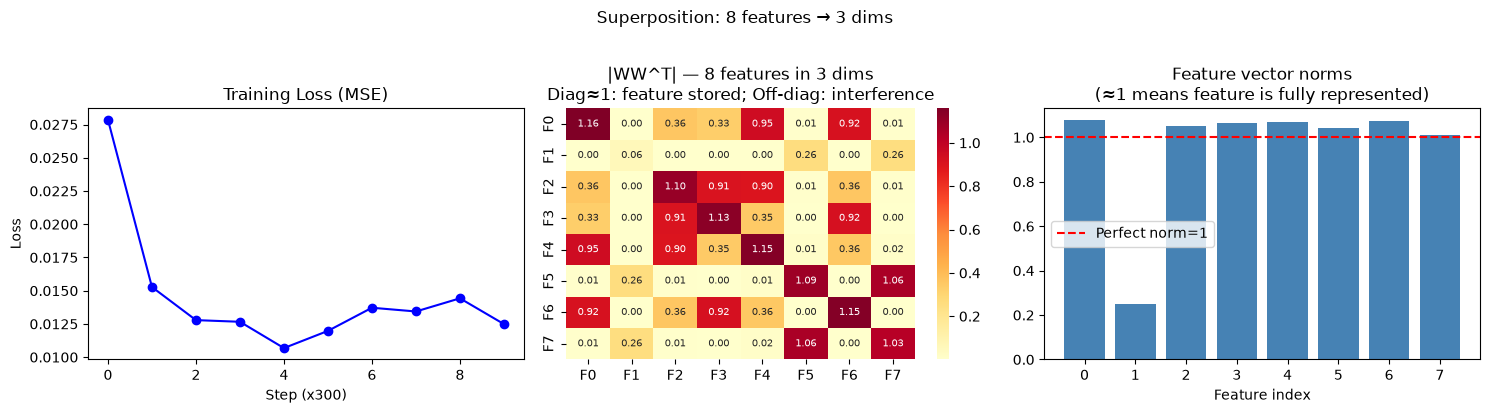

Avg diagonal of |WW^T|: 0.983 (want ≈ 1.0)
Avg off-diagonal:       0.286 (want ≈ 0)

Conclusion: Model stores 8 features in only 3 dimensions via superposition!


In [3]:
# ── Superposition Demo ──
# Compress N=8 features into D=3 dimensions
# Optimal: features should be arranged as vertices of a polytope

N_FEATURES, D_DIM = 8, 3

class SuperpositionModel(nn.Module):
    def __init__(self, n, d):
        super().__init__()
        self.W = nn.Parameter(torch.randn(n, d) * 0.3)   # (n_features, d_dim)
        self.b = nn.Parameter(torch.zeros(n))
    def forward(self, x):
        h = x @ self.W          # (batch, n) x (n, d) → (batch, d)
        out = h @ self.W.T + self.b  # (batch, d) x (d, n) → (batch, n)
        return torch.relu(out)

def sparse_batch(batch, n, sparsity=0.85):
    x = torch.rand(batch, n)
    mask = (torch.rand(batch, n) > sparsity).float()
    return x * mask

torch.manual_seed(0)
sup_model = SuperpositionModel(N_FEATURES, D_DIM)
opt2 = optim.Adam(sup_model.parameters(), lr=2e-3)

losses = []
for step in range(3000):
    x = sparse_batch(256, N_FEATURES)
    xhat = sup_model(x)
    loss = nn.MSELoss()(xhat, x)
    opt2.zero_grad(); loss.backward(); opt2.step()
    if step % 300 == 0: losses.append(loss.item())

# W has shape (N, D); each row = feature vector in D-dim space
W = sup_model.W.detach().numpy()   # (8, 3)
WWT = W @ W.T                      # (8, 8): how much features share space

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(losses, 'b-o')
axes[0].set_title('Training Loss (MSE)')
axes[0].set_xlabel('Step (x300)'); axes[0].set_ylabel('Loss')

sns.heatmap(np.abs(WWT), ax=axes[1], cmap='YlOrRd',
            xticklabels=[f'F{i}' for i in range(N_FEATURES)],
            yticklabels=[f'F{i}' for i in range(N_FEATURES)],
            annot=True, fmt='.2f', annot_kws={'size': 7})
axes[1].set_title(f'|WW^T| — {N_FEATURES} features in {D_DIM} dims\nDiag≈1: feature stored; Off-diag: interference')

# Feature norms
norms = np.linalg.norm(W, axis=1)
axes[2].bar(range(N_FEATURES), norms, color='steelblue')
axes[2].axhline(1.0, color='red', linestyle='--', label='Perfect norm=1')
axes[2].set_title('Feature vector norms\n(≈1 means feature is fully represented)')
axes[2].set_xlabel('Feature index'); axes[2].legend()

plt.suptitle(f'Superposition: {N_FEATURES} features → {D_DIM} dims', y=1.02)
plt.tight_layout()
plt.show()

print(f'Avg diagonal of |WW^T|: {np.diag(np.abs(WWT)).mean():.3f} (want ≈ 1.0)')
print(f'Avg off-diagonal:       {(np.sum(np.abs(WWT)) - np.sum(np.abs(np.diag(np.diag(WWT))))) / (N_FEATURES*(N_FEATURES-1)):.3f} (want ≈ 0)')
print(f'\nConclusion: Model stores {N_FEATURES} features in only {D_DIM} dimensions via superposition!')

## 3. Probing Classifiers — What Is Encoded in Hidden States?

A **probing classifier** is a simple (often linear) classifier trained on frozen hidden representations to test what information is linearly decodable.

$$h = f_{\theta}(x) \quad \text{(frozen)}, \qquad \hat{y} = \text{softmax}(W_{\text{probe}} \cdot h)$$

If the probe achieves high accuracy → the property is encoded in $h$.
If the probe fails → the property is not linearly decodable from $h$.

Main model accuracy: 0.999


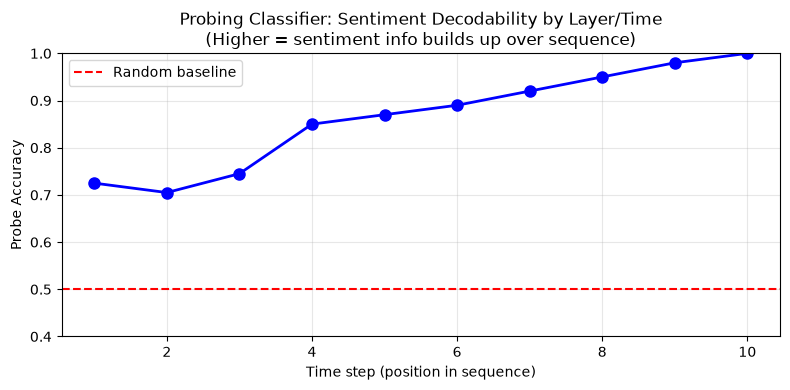


Probe accuracy at t=1: 0.725
Probe accuracy at t=10: 1.000
→ Sentiment information accumulates as the RNN reads more tokens


In [4]:
# ── Probing experiment ──
# Task: learn to predict sentiment (0/1) from text, then probe hidden layers
# We'll use a tiny RNN-like model with synthetic data

torch.manual_seed(1)
np.random.seed(1)

# Synthetic sequences: positive sentiment = more even tokens, negative = more odd tokens
VOCAB, SEQ_LEN, N_SAMPLES = 20, 10, 1000

def make_data():
    X, y = [], []
    for _ in range(N_SAMPLES):
        label = np.random.randint(2)
        seq = []
        for _ in range(SEQ_LEN):
            if label == 1:  # positive: bias toward even tokens
                weights = np.array([1.4 if i%2==0 else 0.6 for i in range(VOCAB)], dtype=float)
            else:           # negative: bias toward odd tokens
                weights = np.array([0.6 if i%2==0 else 1.4 for i in range(VOCAB)], dtype=float)
            weights /= weights.sum()
            t = np.random.choice(VOCAB, p=weights)
            seq.append(t)
        X.append(seq); y.append(label)
    return torch.tensor(X, dtype=torch.long), torch.tensor(y, dtype=torch.long)

X_data, y_data = make_data()

class TinyRNN(nn.Module):
    def __init__(self, vocab, emb, hidden):
        super().__init__()
        self.emb = nn.Embedding(vocab, emb)
        self.rnn = nn.GRU(emb, hidden, batch_first=True)
        self.fc  = nn.Linear(hidden, 2)
    def forward(self, x, return_hidden=False):
        e = self.emb(x)
        out, h = self.rnn(e)
        final = h.squeeze(0)
        if return_hidden:
            return self.fc(final), out  # (B, 2), (B, T, hidden)
        return self.fc(final)

rnn_model = TinyRNN(VOCAB, 8, 16)
rnn_opt = optim.Adam(rnn_model.parameters(), lr=5e-3)
for _ in range(200):
    logits = rnn_model(X_data)
    loss = nn.CrossEntropyLoss()(logits, y_data)
    rnn_opt.zero_grad(); loss.backward(); rnn_opt.step()

with torch.no_grad(): logits = rnn_model(X_data)
acc_main = (logits.argmax(1) == y_data).float().mean().item()
print(f'Main model accuracy: {acc_main:.3f}')

# ── Probe each time step ──
with torch.no_grad():
    _, hidden_all = rnn_model(X_data, return_hidden=True)  # (B, T, 16)

probe_accs = []
for t in range(SEQ_LEN):
    h_t = hidden_all[:, t, :].numpy()  # (B, 16)
    probe = LogisticRegression(max_iter=300, C=1.0)
    probe.fit(h_t[:800], y_data[:800].numpy())
    probe_accs.append(probe.score(h_t[800:], y_data[800:].numpy()))

plt.figure(figsize=(8, 4))
plt.plot(range(1, SEQ_LEN+1), probe_accs, 'b-o', linewidth=2, markersize=8)
plt.axhline(0.5, color='red', linestyle='--', label='Random baseline')
plt.xlabel('Time step (position in sequence)')
plt.ylabel('Probe Accuracy')
plt.title('Probing Classifier: Sentiment Decodability by Layer/Time\n(Higher = sentiment info builds up over sequence)')
plt.legend(); plt.grid(alpha=0.3); plt.ylim(0.4, 1.0)
plt.tight_layout(); plt.show()

print(f'\nProbe accuracy at t=1: {probe_accs[0]:.3f}')
print(f'Probe accuracy at t={SEQ_LEN}: {probe_accs[-1]:.3f}')
print('→ Sentiment information accumulates as the RNN reads more tokens')

## 4. Tiny Transformer — Attention Head Analysis

We build a minimal 2-layer, 2-head transformer from scratch and analyse what its attention heads learn. We're looking for **induction heads** — heads that implement the pattern:

> If `[A][B]` has appeared before, when we see `[A]` again, attend back to the previous `[B]`

This is the fundamental mechanism behind in-context learning.

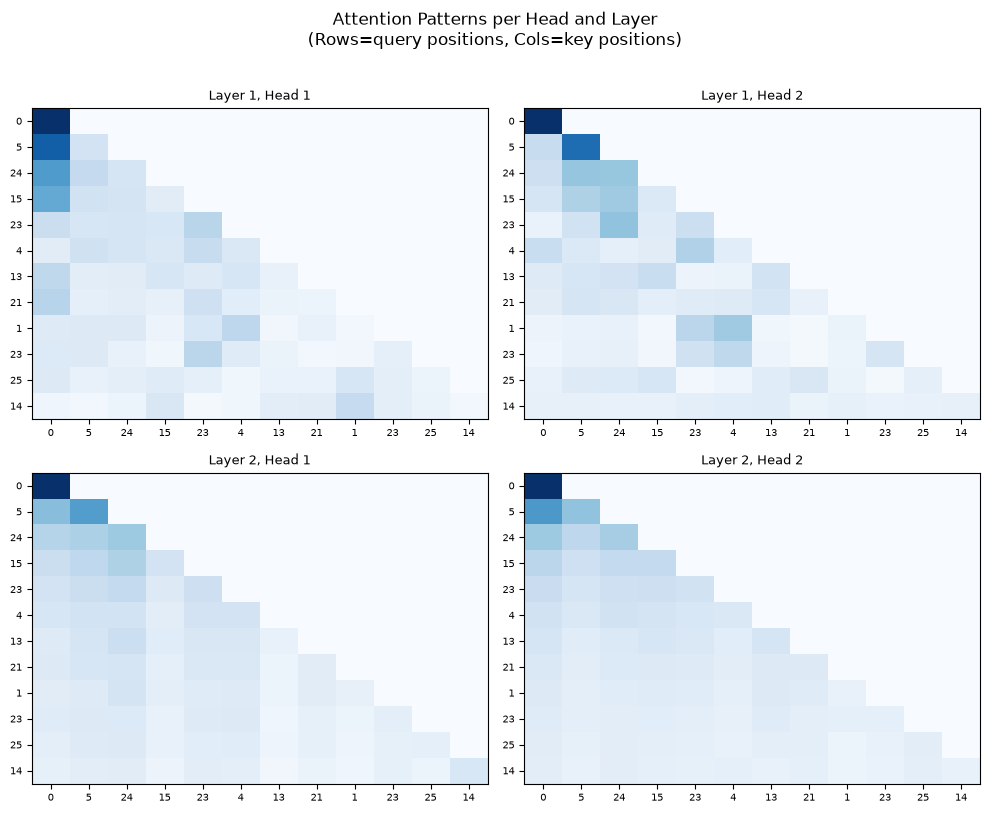

Attention pattern visualisation complete.
Look for: diagonal patterns (attend to self), vertical stripes (attend to specific tokens)


In [5]:
# ── Tiny Transformer ──
VOCAB_T, D_MODEL, N_HEADS, N_LAYERS, SEQ = 32, 16, 2, 2, 12

class MultiHeadAttn(nn.Module):
    def __init__(self, d, h):
        super().__init__()
        self.h, self.dh = h, d // h
        self.qkv = nn.Linear(d, 3 * d, bias=False)
        self.out = nn.Linear(d, d, bias=False)
    def forward(self, x):
        B, T, D = x.shape
        q, k, v = self.qkv(x).split(D, dim=-1)
        def reshape(t): return t.view(B, T, self.h, self.dh).transpose(1, 2)
        q, k, v = reshape(q), reshape(k), reshape(v)
        scores = q @ k.transpose(-2, -1) / (self.dh ** 0.5)
        # causal mask
        mask = torch.triu(torch.ones(T, T, device=x.device), diagonal=1).bool()
        scores = scores.masked_fill(mask.unsqueeze(0).unsqueeze(0), -1e9)
        attn = scores.softmax(-1)   # (B, H, T, T)
        out = (attn @ v).transpose(1, 2).reshape(B, T, D)
        return self.out(out), attn

class TBlock(nn.Module):
    def __init__(self, d, h):
        super().__init__()
        self.attn = MultiHeadAttn(d, h)
        self.ln1, self.ln2 = nn.LayerNorm(d), nn.LayerNorm(d)
        self.ff = nn.Sequential(nn.Linear(d, 4*d), nn.GELU(), nn.Linear(4*d, d))
    def forward(self, x):
        a, attn_w = self.attn(self.ln1(x))
        x = x + a
        x = x + self.ff(self.ln2(x))
        return x, attn_w

class TinyTransformer(nn.Module):
    def __init__(self):
        super().__init__()
        self.emb = nn.Embedding(VOCAB_T, D_MODEL)
        self.pos = nn.Embedding(SEQ, D_MODEL)
        self.blocks = nn.ModuleList([TBlock(D_MODEL, N_HEADS) for _ in range(N_LAYERS)])
        self.ln = nn.LayerNorm(D_MODEL)
        self.head = nn.Linear(D_MODEL, VOCAB_T, bias=False)
    def forward(self, x, return_attn=False):
        B, T = x.shape
        pos = torch.arange(T, device=x.device).unsqueeze(0)
        h = self.emb(x) + self.pos(pos)
        attn_maps = []
        for blk in self.blocks:
            h, aw = blk(h)
            attn_maps.append(aw)
        logits = self.head(self.ln(h))
        if return_attn: return logits, attn_maps
        return logits

torch.manual_seed(7)
tf = TinyTransformer()
optT = optim.Adam(tf.parameters(), lr=3e-3)

# Train on random next-token prediction
for step in range(400):
    xb = torch.randint(0, VOCAB_T, (32, SEQ))
    logits = tf(xb)
    loss = nn.CrossEntropyLoss()(logits[:, :-1].reshape(-1, VOCAB_T), xb[:, 1:].reshape(-1))
    optT.zero_grad(); loss.backward(); optT.step()

# Visualise attention patterns on a test sequence
test_seq = torch.randint(0, VOCAB_T, (1, SEQ))
with torch.no_grad():
    _, attn_maps = tf(test_seq, return_attn=True)

fig, axes = plt.subplots(N_LAYERS, N_HEADS, figsize=(10, 8))
tokens = [str(t.item()) for t in test_seq[0]]
for layer_idx, aw in enumerate(attn_maps):
    for head_idx in range(N_HEADS):
        ax = axes[layer_idx, head_idx]
        mat = aw[0, head_idx].numpy()  # (T, T)
        im = ax.imshow(mat, vmin=0, vmax=1, cmap='Blues', aspect='auto')
        ax.set_title(f'Layer {layer_idx+1}, Head {head_idx+1}', fontsize=9)
        ax.set_xticks(range(SEQ)); ax.set_xticklabels(tokens, fontsize=7)
        ax.set_yticks(range(SEQ)); ax.set_yticklabels(tokens, fontsize=7)

plt.suptitle('Attention Patterns per Head and Layer\n(Rows=query positions, Cols=key positions)', y=1.01)
plt.tight_layout()
plt.show()
print('Attention pattern visualisation complete.')
print('Look for: diagonal patterns (attend to self), vertical stripes (attend to specific tokens)')

## 5. Activation Patching — Causal Tracing

**Activation patching** (also called causal tracing) identifies *which specific activations are causally responsible* for a particular model output.

**Algorithm:**
1. Run model on clean input → record all activations
2. Run model on corrupted input → record all activations
3. For each activation position, *patch* it: run on corrupted input but replace activation $i$ with clean version
4. Observe how much the output recovers → higher recovery = activation $i$ is important

$$\text{Recovery}(i) = \frac{f(x_{\text{corrupt}})[\text{patched at } i] - f(x_{\text{corrupt}})}{f(x_{\text{clean}}) - f(x_{\text{corrupt}})}$$

Clean logit:   -0.1131
Corrupt logit: -0.1082
Difference:    -0.0049


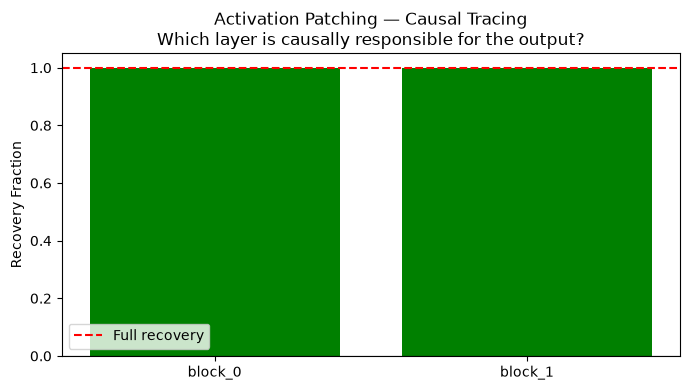

block_0: recovery = 1.000
block_1: recovery = 1.000


In [6]:
# ── Activation Patching on Tiny Transformer ──
# Clean input: sequence A = [5, 3, 7, 1, 2, 0, 4, 8, 6, 9, 5, 3]
# Corrupted:   replace token at pos 0 with a different token

torch.manual_seed(42)
clean_seq = torch.tensor([[5, 3, 7, 1, 2, 0, 4, 8, 6, 9, 5, 3]])
corrupt_seq = clean_seq.clone(); corrupt_seq[0, 0] = 15  # change first token

# Target: logit for token 7 at position 2 (after seeing 5,3)
target_pos, target_tok = 1, 7  # logit at pos 1 for class 7

def get_logit(seq):
    with torch.no_grad():
        return tf(seq)[0, target_pos, target_tok].item()

logit_clean  = get_logit(clean_seq)
logit_corrupt = get_logit(corrupt_seq)
print(f'Clean logit:   {logit_clean:.4f}')
print(f'Corrupt logit: {logit_corrupt:.4f}')
print(f'Difference:    {logit_clean - logit_corrupt:.4f}')

# Cache clean activations at each block input
clean_cache = {}
hooks = []
def make_hook(name):
    def hook(module, inp, out):
        clean_cache[name] = out[0].detach() if isinstance(out, tuple) else out.detach()
    return hook

for i, blk in enumerate(tf.blocks):
    h = blk.register_forward_hook(make_hook(f'block_{i}'))
    hooks.append(h)
with torch.no_grad(): tf(clean_seq)
for h in hooks: h.remove()

# Now patch each block on corrupted run
recoveries = {}
for patch_name, patch_val in clean_cache.items():
    patch_hooks = []
    def make_patch(cached):
        def ph(module, inp, out):
            if isinstance(out, tuple): return (cached,) + out[1:]
            return cached
        return ph
    for i, blk in enumerate(tf.blocks):
        if f'block_{i}' == patch_name:
            h = blk.register_forward_hook(make_patch(patch_val))
            patch_hooks.append(h)
    with torch.no_grad():
        patched_logit = tf(corrupt_seq)[0, target_pos, target_tok].item()
    for h in patch_hooks: h.remove()
    recovery = (patched_logit - logit_corrupt) / (logit_clean - logit_corrupt + 1e-8)
    recoveries[patch_name] = recovery

names = list(recoveries.keys())
vals = [recoveries[n] for n in names]

plt.figure(figsize=(7, 4))
bars = plt.bar(names, vals, color=['green' if v > 0.3 else 'steelblue' for v in vals])
plt.axhline(0, color='black', lw=0.8)
plt.axhline(1.0, color='red', linestyle='--', label='Full recovery')
plt.ylabel('Recovery Fraction')
plt.title('Activation Patching — Causal Tracing\nWhich layer is causally responsible for the output?')
plt.legend(); plt.tight_layout(); plt.show()

for n, v in zip(names, vals):
    print(f'{n}: recovery = {v:.3f}')

## 6. Feature Visualisation — What Does a Neuron Maximally Respond To?

For a CNN (or any differentiable model), we can find the input that **maximises** a neuron's activation by gradient ascent in input space:

$$x^* = \arg\max_x A_k(x) - \lambda \|x\|^2$$

Updated via: $x \leftarrow x + \alpha \nabla_x A_k(x)$

This reveals the "ideal stimulus" for that neuron — its preferred feature.

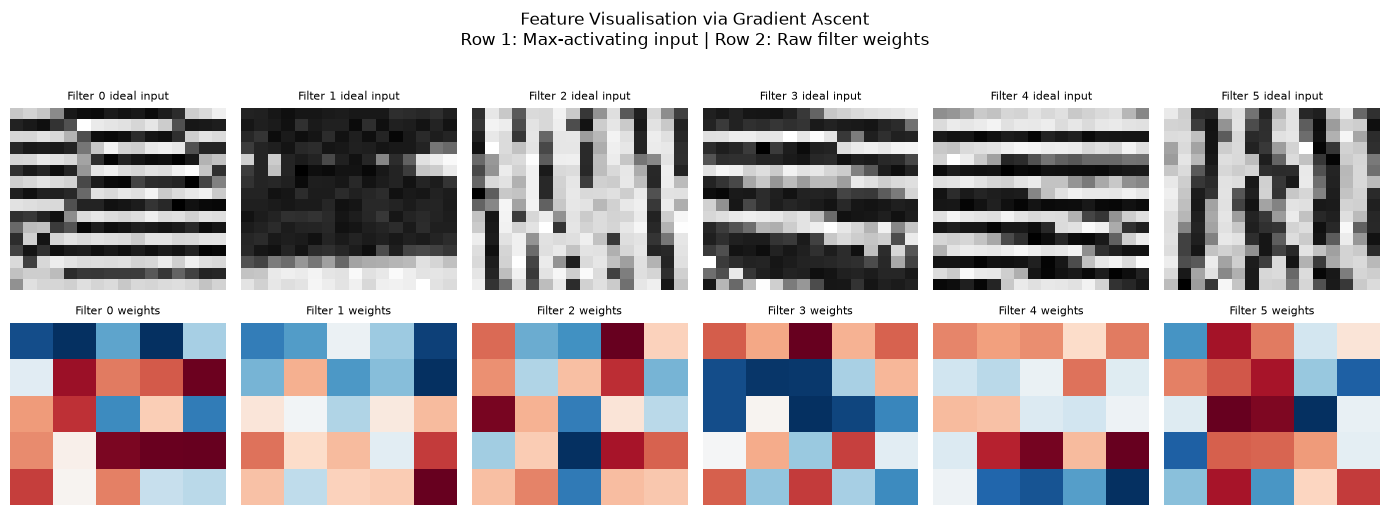

Horizontal filters → maximally activated by horizontal patterns
Vertical filters   → maximally activated by vertical patterns


In [7]:
# ── Feature Visualisation via Gradient Ascent ──
# Use a small CNN with 3 filters; visualise what each filter maximally responds to

class SmallCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 6, kernel_size=5, padding=2)  # 6 filters
        self.pool  = nn.MaxPool2d(2)
        self.fc    = nn.Linear(6 * 8 * 8, 2)
    def forward(self, x):
        x = torch.relu(self.conv1(x))
        x = self.pool(x)
        return self.fc(x.view(x.size(0), -1))
    def get_conv_activation(self, x):
        return torch.relu(self.conv1(x))  # (1, 6, 16, 16)

# Train briefly on MNIST-like synthetic data (16x16 images)
torch.manual_seed(3)
cnn = SmallCNN()
opt_cnn = optim.Adam(cnn.parameters(), lr=1e-3)
# Synthetic: positive = horizontal bars, negative = vertical bars
for _ in range(300):
    bs = 32
    imgs = torch.zeros(bs, 1, 16, 16)
    lbls = torch.randint(0, 2, (bs,))
    for b in range(bs):
        if lbls[b] == 0:
            rows = np.random.choice(16, 4, replace=False)
            imgs[b, 0, rows, :] = 1.0
        else:
            cols = np.random.choice(16, 4, replace=False)
            imgs[b, 0, :, cols] = 1.0
    imgs += torch.randn_like(imgs) * 0.1
    loss = nn.CrossEntropyLoss()(cnn(imgs), lbls)
    opt_cnn.zero_grad(); loss.backward(); opt_cnn.step()

# Gradient ascent: maximise activation of each filter
n_filters = 6
fig, axes = plt.subplots(2, n_filters, figsize=(14, 5))

for f_idx in range(n_filters):
    x_vis = torch.randn(1, 1, 16, 16, requires_grad=True)
    opt_vis = optim.Adam([x_vis], lr=0.05)
    for _ in range(200):
        act = cnn.get_conv_activation(x_vis)          # (1, 6, 16, 16)
        obj = act[0, f_idx].mean() - 0.01 * (x_vis**2).mean()
        opt_vis.zero_grad(); (-obj).backward(); opt_vis.step()
    
    vis_img = x_vis.detach().numpy()[0, 0]
    axes[0, f_idx].imshow(vis_img, cmap='gray', aspect='auto')
    axes[0, f_idx].set_title(f'Filter {f_idx} ideal input', fontsize=8)
    axes[0, f_idx].axis('off')
    
    # Also show the actual learned filter weights
    filt = cnn.conv1.weight[f_idx, 0].detach().numpy()
    axes[1, f_idx].imshow(filt, cmap='RdBu_r', aspect='auto')
    axes[1, f_idx].set_title(f'Filter {f_idx} weights', fontsize=8)
    axes[1, f_idx].axis('off')

axes[0, 0].set_ylabel('Grad Ascent\nVisualization', fontsize=8)
axes[1, 0].set_ylabel('Raw Filter\nWeights', fontsize=8)
plt.suptitle('Feature Visualisation via Gradient Ascent\nRow 1: Max-activating input | Row 2: Raw filter weights', y=1.02)
plt.tight_layout(); plt.show()
print('Horizontal filters → maximally activated by horizontal patterns')
print('Vertical filters   → maximally activated by vertical patterns')

## 7. Summary — The Mechanistic Interpretability Toolkit

| Tool | What It Finds | When to Use |
|------|--------------|-------------|
| **Weight inspection** | Neuron directions in weight space | Simple MLPs, attention matrices |
| **Probing classifiers** | What info is linearly decodable at layer $l$ | Finding where representations emerge |
| **Activation patching** | Which activations are causally necessary | Tracing which components cause a behaviour |
| **Superposition analysis** | How many features share each dimension | Model capacity analysis |
| **Feature visualisation** | What input maximally activates a neuron | CNN filter interpretation |
| **Logit lens** | What the model predicts at each layer | GPT residual stream analysis |

### Key Findings from the Field
- **Modular arithmetic**: transformers implement modular addition circuits using Fourier analysis internally
- **Induction heads** (Layer 1 of most GPTs): implement in-context learning
- **Superposition is ubiquitous**: almost all production models use it
- **Polysemanticity is real**: single neurons encode 10s–100s of distinct concepts

## Additional Learning Resources

1. **Anthropic: Toy Models of Superposition** — https://transformer-circuits.pub/2022/toy_model/index.html — The foundational superposition paper
2. **Anthropic: A Mathematical Framework for Transformer Circuits** — https://transformer-circuits.pub/2021/framework/index.html — Circuits and induction heads
3. **Neel Nanda: Progress Measures for Grokking via Mechanistic Interpretability** — https://arxiv.org/abs/2301.05217 — Circuits behind memorisation → generalisation
4. **EleutherAI: Representation Engineering** — https://arxiv.org/abs/2310.01405 — Control model behaviour via representation vectors
5. **Anthropic: Scaling Monosemanticity** — https://transformer-circuits.pub/2024/scaling-monosemanticity/index.html — Finding interpretable features in large models
6. **TransformerLens Library** — https://github.com/neelnanda-io/TransformerLens — Toolkit for mechanistic interpretability
7. **ARENA Curriculum** — https://arena3-chapter1-transformer-interp.streamlit.app/ — Hands-on mechanistic interp exercises
8. **Anthropic: Circuits Thread** — https://distill.pub/2020/circuits/ — Original circuits hypothesis series on Distill.pub